# Projeto: Detecção de Covid-19 via Padrões de Batimentos Cardíacos com KNN
Este notebook processa dados fisiológicos de 16 pacientes, extrai características estatísticas das séries temporais de batimentos cardíacos e aplica o algoritmo **KNN (K-Nearest Neighbors)** para classificar se o paciente testou positivo ou negativo para Covid-19, gerando uma visualização gráfica da fronteira de decisão.

In [13]:
import os
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

plt.style.use('ggplot')

In [14]:
PASTA_DADOS = "dados" 

# Substitua pela lista real dos seus 20 pares de arquivos
mapeamento_pacientes = [
    {"json": "P1.json", "csv": "P1.csv"},
    {"json": "P2.json", "csv": "P2.csv"},
    {"json": "P3.json", "csv": "P3.csv"},
    {"json": "P4.json", "csv": "P4.csv"},
    {"json": "P5.json", "csv": "P5.csv"},
    {"json": "P6.json", "csv": "P6.csv"},
    {"json": "P7.json", "csv": "P7.csv"},
    {"json": "P8.json", "csv": "P8.csv"},
    {"json": "P9.json", "csv": "P9.csv"},
    {"json": "P10.json", "csv": "P10.csv"},
    {"json": "P11.json", "csv": "P11.csv"},
    {"json": "P12.json", "csv": "P12.csv"},
    {"json": "P13.json", "csv": "P13.csv"},
    {"json": "P14.json", "csv": "P14.csv"},
    {"json": "P15.json", "csv": "P15.csv"},
    {"json": "P16.json", "csv": "P16.csv"},
    {"json": "P17.json", "csv": "P17.csv"},
    {"json": "P18.json", "csv": "P18.csv"},
    {"json": "P19.json", "csv": "P19.csv"},
    {"json": "P20.json", "csv": "P20.csv"}
]

In [15]:
DIAS_CRITICOS = 5
TAMANHO_JANELA = 7

dados_consolidados = []

for par in mapeamento_pacientes:
    caminho_json = os.path.join(PASTA_DADOS, par["json"])
    caminho_csv = os.path.join(PASTA_DADOS, par["csv"])
    
    if not os.path.exists(caminho_json) or not os.path.exists(caminho_csv):
        continue
        
    with open(caminho_json, 'r') as f:
        conteudo_json = json.load(f)
    
    # Extrai o histórico e aplica regra de 5 alertas '2' em 7 dias
    alertas = pd.Series([int(item['val']) for item in conteudo_json['nightsignal']])
    is_alerta_2 = (alertas == 2)
    alertas_na_janela = is_alerta_2.rolling(window=TAMANHO_JANELA).sum()
    situacao_alarmante = 1 if alertas_na_janela.max() >= DIAS_CRITICOS else 0
    
    df_csv = pd.read_csv(caminho_csv)
    dados_consolidados.append({
        'Media_HR': df_csv['HR_Value'].mean(),
        'Variabilidade_HR': df_csv['HR_Value'].std(),
        'Situacao_Alarmante': situacao_alarmante
    })

df_projeto = pd.DataFrame(dados_consolidados)
print(f"Base consolidada: {len(df_projeto)} pacientes processados.")

Base consolidada: 20 pacientes processados.


In [16]:
X = df_projeto[['Media_HR', 'Variabilidade_HR']].values
y = df_projeto['Situacao_Alarmante'].values

# Divisão aleatória: 16 treino / 4 teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=4, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Controle de vizinhos (K=3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

print(f"Acurácia nos 4 pacientes de teste: {accuracy_score(y_test, knn.predict(X_test_scaled)) * 100:.1f}%")

Acurácia nos 4 pacientes de teste: 50.0%


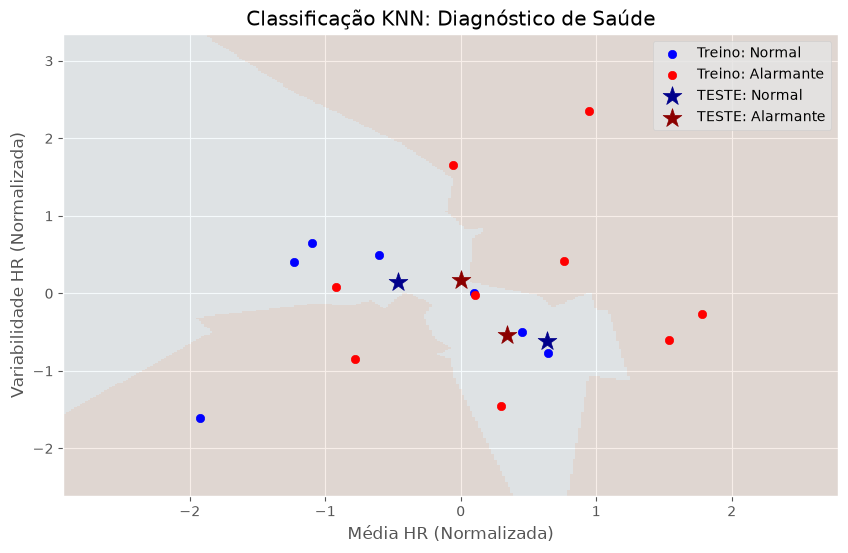

In [17]:
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 6))
plt.pcolormesh(xx, yy, Z, alpha=0.1, cmap=plt.cm.Paired, shading='auto')

# Pontos de Treino
plt.scatter(X_train_scaled[y_train == 0, 0], X_train_scaled[y_train == 0, 1], color='blue', label='Treino: Normal')
plt.scatter(X_train_scaled[y_train == 1, 0], X_train_scaled[y_train == 1, 1], color='red', label='Treino: Alarmante')

# Pontos de Teste (Estrelas)
plt.scatter(X_test_scaled[y_test == 0, 0], X_test_scaled[y_test == 0, 1], color='darkblue', marker='*', s=200, label='TESTE: Normal')
plt.scatter(X_test_scaled[y_test == 1, 0], X_test_scaled[y_test == 1, 1], color='darkred', marker='*', s=200, label='TESTE: Alarmante')

plt.title('Classificação KNN: Diagnóstico de Saúde')
plt.xlabel('Média HR (Normalizada)')
plt.ylabel('Variabilidade HR (Normalizada)')
plt.legend()
plt.show()